In [ ]:
# I built a House Price Prediction model using Linear Regression in Python. 
# I split the data 80/20 for training and testing, evaluated using R2 Score and RMSE(Root Mean Squared Error), 
# and visualised actual vs predicted prices. 
# The model achieved an R2 of 0.9724369952260825 — meaning it explained  97.24% of the variance in house prices.

In [ ]:
# Step 1 — Install & Import Libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [6]:
# Step 2 — Get the Dataset


df = pd.read_csv(r'E:\AIML THINGS\Projects\house_prices_practice.csv')

In [7]:
df.head(5)

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


# Step 3 — Explore the Data (EDA)

In [14]:
# Check shape and info

In [ ]:
df.shape

(300, 10)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-null    int64
 3   GarageCars    300 non-null    int64
 4   TotalBsmtSF   300 non-null    int64
 5   YearBuilt     300 non-null    int64
 6   FullBath      300 non-null    int64
 7   BedroomAbvGr  300 non-null    int64
 8   LotArea       300 non-null    int64
 9   SalePrice     300 non-null    int64
dtypes: int64(10)
memory usage: 23.6 KB


In [11]:
df.describe()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,5.326667,2307.386667,1.330000,1468.796667,1986.163333,1.523333,2.926667,8969.453333,252262.903333
std,86.746758,2.873001,1042.561303,1.109898,672.333705,21.377089,1.131543,1.456604,3753.531132,74998.055214
min,1.000000,1.000000,504.000000,0.000000,303.000000,1950.000000,0.000000,1.000000,2009.000000,82494.000000
25%,75.750000,3.000000,1392.250000,0.000000,903.000000,1967.000000,0.000000,2.000000,5996.250000,190355.250000
50%,150.500000,5.000000,2265.500000,1.000000,1502.000000,1986.000000,2.000000,3.000000,9031.000000,251292.500000
75%,225.250000,8.000000,3306.500000,2.000000,2129.500000,2004.250000,3.000000,4.000000,12316.000000,307105.000000
max,300.000000,10.000000,3998.000000,3.000000,2492.000000,2023.000000,3.000000,5.000000,14987.000000,435291.000000


In [10]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Check missing values
df.isnull().sum()

Id              0
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64

In [13]:
# See Correlation
df.corr()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
Id,1.000000,-0.158700,0.050807,-0.008250,-0.024281,0.037105,0.064142,-0.006326,-0.060973,-0.025416
OverallQual,-0.158700,1.000000,-0.116413,-0.017138,0.008098,0.005990,-0.047619,-0.056594,-0.030605,0.352899
GrLivArea,0.050807,-0.116413,1.000000,0.056380,0.023471,0.032073,0.103215,-0.090480,-0.035433,0.745095
GarageCars,-0.008250,-0.017138,0.056380,1.000000,0.051605,-0.031599,0.125668,0.083287,-0.005316,0.351321
TotalBsmtSF,-0.024281,0.008098,0.023471,0.051605,1.000000,-0.050187,0.042792,-0.039197,-0.007753,0.250178
YearBuilt,0.037105,0.005990,0.032073,-0.031599,-0.050187,1.000000,0.020098,-0.040859,0.091507,0.222142
FullBath,0.064142,-0.047619,0.103215,0.125668,0.042792,0.020098,1.000000,0.037567,-0.061729,0.273731
BedroomAbvGr,-0.006326,-0.056594,-0.090480,0.083287,-0.039197,-0.040859,0.037567,1.000000,-0.000527,0.014113
LotArea,-0.060973,-0.030605,-0.035433,-0.005316,-0.007753,0.091507,-0.061729,-0.000527,1.000000,-0.038982
SalePrice,-0.025416,0.352899,0.745095,0.351321,0.250178,0.222142,0.273731,0.014113,-0.038982,1.000000


# Step 4 — Clean the Data

In [15]:
# Drop nulls if any
df.dropna()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656
...,...,...,...,...,...,...,...,...,...,...
295,296,1,3495,1,1792,1954,2,5,4978,250604
296,297,5,3438,3,1266,2003,0,1,9373,329906
297,298,6,1992,0,1148,1996,1,1,7907,184623
298,299,3,3722,1,1407,1998,1,1,8097,303345


In [ ]:
# Remove duplicates

df.drop_duplicates()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656
...,...,...,...,...,...,...,...,...,...,...
295,296,1,3495,1,1792,1954,2,5,4978,250604
296,297,5,3438,3,1266,2003,0,1,9373,329906
297,298,6,1992,0,1148,1996,1,1,7907,184623
298,299,3,3722,1,1407,1998,1,1,8097,303345


In [17]:
print("Clean data shape:", df.shape)

Clean data shape: (300, 10)


In [19]:
df.columns

Index(['Id', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
       'YearBuilt', 'FullBath', 'BedroomAbvGr', 'LotArea', 'SalePrice'],
      dtype='str')

# Step 5 — Split Features and Target

In [20]:
df.head(3)

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609


In [47]:
# X = input features, y = what we want to predict
X = df[['GrLivArea', 'YearBuilt', 'LotArea',
        'OverallQual',   # Overall quality rating — very powerful!
        'TotalBsmtSF',   # Basement area
        'GarageCars',    # Garage size
        'FullBath',      # Number of bathrooms
        'BedroomAbvGr'   # Bedrooms
        ]]
y = df['SalePrice']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (300, 8)
Target shape: (300,)


# Step 6 — Train Test Split

In [48]:
# 80% for training, 20% for testing

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

# Step 7 — Build the Model

In [49]:
# Create and train the model

model = LinearRegression()
model.fit(X_train, y_train)


print("Model trained successfully!")
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Model trained successfully!
Coefficients: [ 5.54102571e+01  7.46370978e+02 -1.59522108e-01  1.19146881e+04
  2.51990182e+01  1.91096416e+04  1.10403430e+04  4.81206199e+03]
Intercept: -1512820.56843162


# Step 8 — Make Predictions

In [50]:
# Predict on test data

y_pred = model.predict(X_test)

In [51]:
# See predicted vs actual
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred.round(0)
})
print(results)

    Actual Price  Predicted Price
0         224163         239161.0
1         203881         190490.0
2         380236         398001.0
3         211664         223169.0
4         122139         135188.0
5         180067         180259.0
6         275810         283708.0
7         209025         204535.0
8         213952         205838.0
9         154885         171505.0
10        395010         389528.0
11        253397         274164.0
12        115204         116221.0
13        189831         171344.0
14        300918         293879.0
15        314526         314821.0
16        135263         154945.0
17        135385         146163.0
18        222449         221221.0
19        250335         255129.0
20        221041         235773.0
21        175831         167431.0
22        206832         208978.0
23        296330         289813.0
24        319876         313189.0
25        385176         382652.0
26        225589         206611.0
27        250604         260775.0
28        2894

# Step 9 — Evaluate the Model

In [52]:

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

# Get R2 Score
r2 = r2_score(y_test, y_pred)

In [60]:
r2

0.9724369952260825

In [53]:
print(f"R2 Percentage : {r2 * 100:.2f}%")

R2 Percentage : 97.24%


# Step 10 — Visualise Results

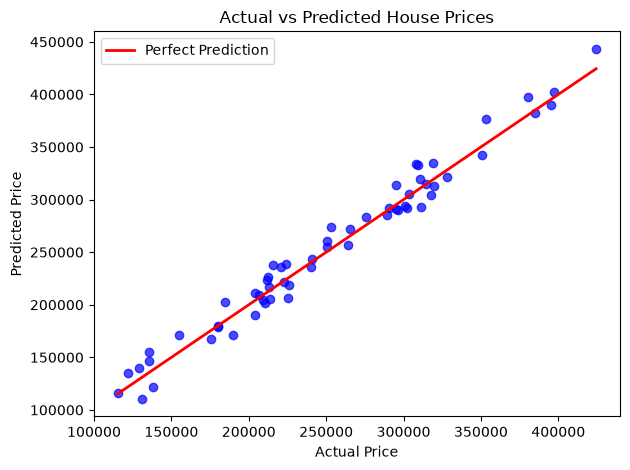

In [54]:
# Actual vs Predicted plot

plt.Figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, label='Perfect Prediction')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.tight_layout()
plt.show()


# Step 11 — Predict a New House

In [56]:
df.head(3)

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609


In [59]:
# Predict price for a new house
new_house = pd.DataFrame({
    'GrLivArea': [1500],    # Living area in sq ft
    'YearBuilt': [2010],    # Year the house was built
    'LotArea':   [8000],     # Lot size in sq ft
    'OverallQual':[6],   # Overall quality rating — very powerful!
    'TotalBsmtSF': [600],   # Basement area
    'GarageCars': [3],    # Garage size
    'FullBath': [2],      # Number of bathrooms
    'BedroomAbvGr': [3]   # Bedrooms
})

predicted_price = model.predict(new_house)
print(f"Predicted Price: ${predicted_price[0]:,.0f}")

Predicted Price: $249,678


In [ ]:
# # Predict 3 different houses at once
# houses = pd.DataFrame({
#     'GrLivArea': [800,  1500, 2500],
#     'YearBuilt': [1980, 2000, 2015],
#     'LotArea':   [5000, 8000, 12000]
# })

# predictions = model.predict(houses)
# for i, price in enumerate(predictions):
#     print(f"House {i+1} predicted price: ${price:,.0f}")

House 1 predicted price: $170,580
House 2 predicted price: $221,700
House 3 predicted price: $284,014


In [61]:
import pickle

# Save the trained model
with open('house_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("✅ Model saved as house_model.pkl")

✅ Model saved as house_model.pkl
